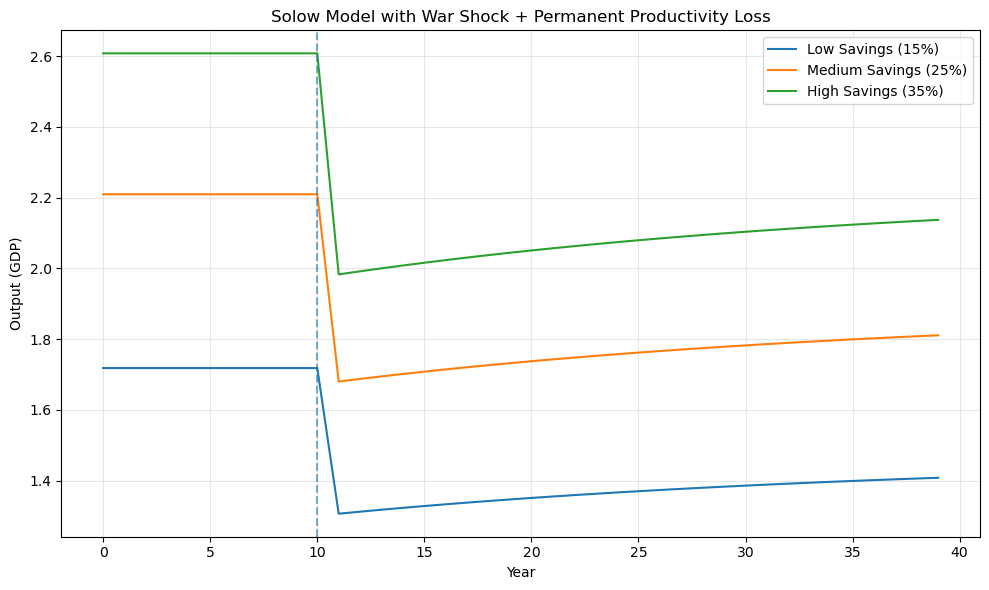

In [1]:
import numpy as np
import matplotlib.pyplot as plt


years = 40
conflict_year = 10

alpha = 0.33
delta = 0.05
shock_size = 0.4       
productivity_loss = 0.10  

s_low = 0.15
s_medium = 0.25
s_high = 0.35



def steady_state_k(s, A):
    return ((s * A) / delta) ** (1 / (1 - alpha))



def simulate_solow(savings_rate):

    A = 1.0  

    K_star = steady_state_k(savings_rate, A)
    K = [K_star]
    Y = []

    for t in range(years):

        output = A * (K[-1] ** alpha)
        Y.append(output)

        # War shock
        if t == conflict_year:
            K.append(K[-1] * (1 - shock_size))
            A = A * (1 - productivity_loss) 
            continue

        new_K = savings_rate * output + (1 - delta) * K[-1]
        K.append(new_K)

    return Y



Y_low = simulate_solow(s_low)
Y_medium = simulate_solow(s_medium)
Y_high = simulate_solow(s_high)



plt.figure(figsize=(10,6))

plt.plot(Y_low, label="Low Savings (15%)")
plt.plot(Y_medium, label="Medium Savings (25%)")
plt.plot(Y_high, label="High Savings (35%)")

plt.axvline(conflict_year, linestyle="--", alpha=0.6)

plt.title("Solow Model with War Shock + Permanent Productivity Loss")
plt.xlabel("Year")
plt.ylabel("Output (GDP)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


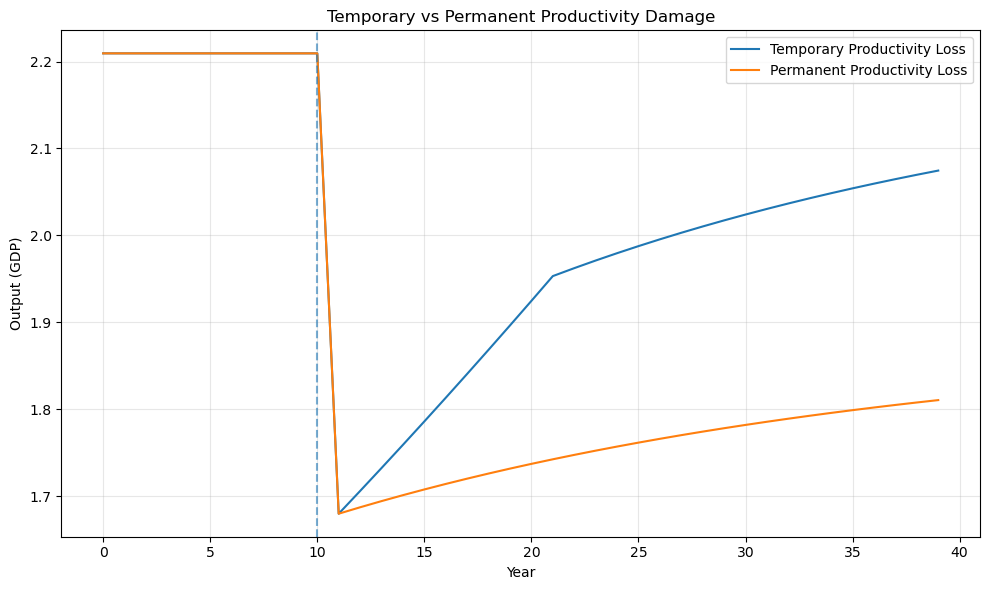

In [2]:
import numpy as np
import matplotlib.pyplot as plt


years = 40
conflict_year = 10

alpha = 0.33
delta = 0.05
shock_size = 0.4
productivity_loss = 0.10

savings_rate = 0.25



def steady_state_k(s, A):
    return ((s * A) / delta) ** (1 / (1 - alpha))



def simulate_temporary():

    A = 1.0
    K_star = steady_state_k(savings_rate, A)
    K = [K_star]
    Y = []

    for t in range(years):

        output = A * (K[-1] ** alpha)
        Y.append(output)

        if t == conflict_year:
            K.append(K[-1] * (1 - shock_size))
            A = A * (1 - productivity_loss)
            continue

       
        if t > conflict_year:
            A += 0.01 
            A = min(A, 1.0)

        new_K = savings_rate * output + (1 - delta) * K[-1]
        K.append(new_K)

    return Y



def simulate_permanent():

    A = 1.0
    K_star = steady_state_k(savings_rate, A)
    K = [K_star]
    Y = []

    for t in range(years):

        output = A * (K[-1] ** alpha)
        Y.append(output)

        if t == conflict_year:
            K.append(K[-1] * (1 - shock_size))
            A = A * (1 - productivity_loss)
            continue

        new_K = savings_rate * output + (1 - delta) * K[-1]
        K.append(new_K)

    return Y



Y_temp = simulate_temporary()
Y_perm = simulate_permanent()


plt.figure(figsize=(10,6))

plt.plot(Y_temp, label="Temporary Productivity Loss")
plt.plot(Y_perm, label="Permanent Productivity Loss")

plt.axvline(conflict_year, linestyle="--", alpha=0.6)

plt.title("Temporary vs Permanent Productivity Damage")
plt.xlabel("Year")
plt.ylabel("Output (GDP)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
